<a href="https://colab.research.google.com/github/arcodeya/kidney-thermal-property-mfnn/blob/main/notebooks/proof_of_concept.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/ECs Master Folder/Research/"
    "Kidney Thermal Property MFNN"
)

RAW_DIR = PROJECT_DIR / "Data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "Data" / "processed"
FIGURES_DIR = PROJECT_DIR / "Figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

file_path = RAW_DIR / "porcine_raw.csv"

if not file_path.exists():
    raise FileNotFoundError(f"Could not find: {file_path}")

df = pd.read_csv(file_path).sort_values("temperature_C").reset_index(drop=True)

T = df["temperature_C"].to_numpy(float)
k = df["conductivity_mean_W_mK"].to_numpy(float)

# Reported 95% expanded uncertainty, not standard deviation.
u = df["conductivity_EU95_W_mK"].to_numpy(float)

display(df)
print("Rows:", len(df))

,species,temperature_C,conductivity_mean_W_mK,conductivity_EU95_W_mK,diffusivity_mean_mm2_s,diffusivity_EU95_mm2_s
0,Porcine,23.9,0.549,0.045,0.155,0.019
1,Porcine,35.4,0.559,0.050,0.157,0.011
2,Porcine,41.5,0.573,0.050,0.161,0.009
3,Porcine,46.2,0.573,0.030,0.163,0.011
4,Porcine,56.7,0.571,0.033,0.161,0.007
5,Porcine,60.0,0.560,0.022,0.160,0.008
6,Porcine,70.1,0.536,0.017,0.165,0.011
7,Porcine,76.4,0.528,0.026,0.171,0.014
8,Porcine,82.3,0.527,0.080,0.178,0.016
9,Porcine,86.6,0.596,0.058,0.194,0.033


Rows: 11


In [ ]:
slope, intercept = np.polyfit(T, k, 1)
k_pred = slope*T+intercept # we calculate r^2, mae, rmse for each of those 11 porcine temp points

r2 = r2_score(k, k_pred) # r^2 value (1=perfect, 0=poor, <0=worse than just the average every time)

# watts per meter-kelvin (unit of thermal conductivity), W/(m*K)
mae = mean_absolute_error(k, k_pred) # mean absolute error
rmse = np.sqrt(mean_squared_error(k, k_pred)) # root mean squared error

T_dense = np.linspace(T.min(), T.max(), 100) # then we generate 100 points on that same polyfit
k_dense = slope * T_dense + intercept # np array

lf_df = pd.DataFrame({
    "temperature_C": T_dense,
    "conductivity_LF_W_mK": k_dense,
})

print(f"k_LF(T) = {slope:.10f}T + {intercept:.10f}")
print(f"R² = {r2:.6f}")
print(f"MAE = {mae:.6f}")
print(f"RMSE = {rmse:.6f}")

k_LF(T) = 0.0004403078T + 0.5385597447
R² = 0.082364
MAE = 0.023724
RMSE = 0.031617


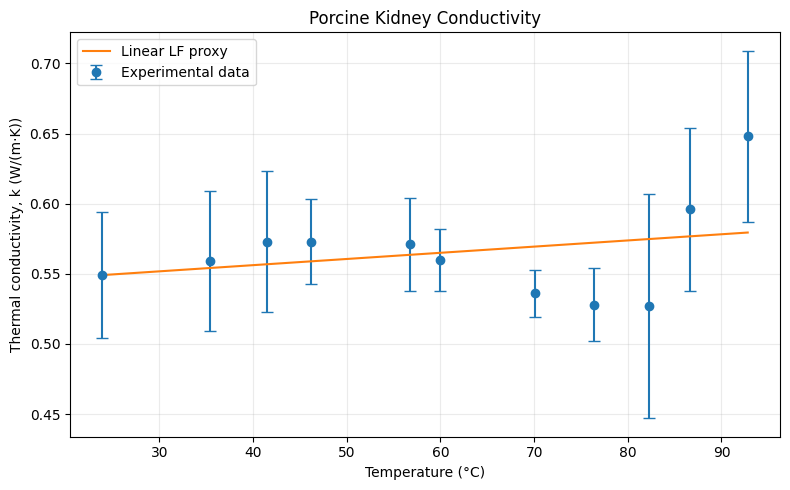

Saved: /content/drive/MyDrive/ECs Master Folder/Research/Kidney Thermal Property MFNN/Figures/porcine_linear_fit.png
Saved: /content/drive/MyDrive/ECs Master Folder/Research/Kidney Thermal Property MFNN/Data/processed/porcine_lf_linear.csv


In [ ]:
plt.figure(figsize=(8, 5))

# for 11 porcine pts
plt.errorbar(
    T, k, yerr=u,
    fmt="o",
    capsize=4,
    label="Experimental data"
)

# plots all 100 pts
plt.plot(
    T_dense, k_dense,
    label="Linear LF proxy"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Thermal conductivity, k (W/(m·K))")
plt.title("Porcine Kidney Conductivity")

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plot_path = FIGURES_DIR / "porcine_linear_fit.png"
csv_path = PROCESSED_DIR / "porcine_lf_linear.csv"

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
lf_df.to_csv(csv_path, index=False)

print("Saved:", plot_path)
print("Saved:", csv_path)